In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors

from tqdm.notebook import tqdm
from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy, PRCASignAlignGreedyV2


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from xaikd.bases import pcalookahead



import numpy as np
import numpy.typing as npt

import os

In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

DATA_SIZE = 0.5


In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

In [7]:
TASK_NUM_CLASSES

[47, 10]

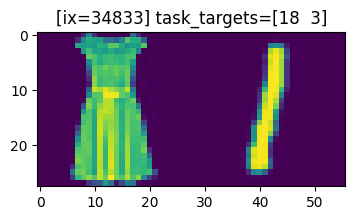

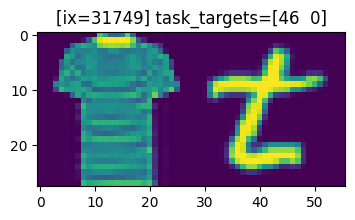

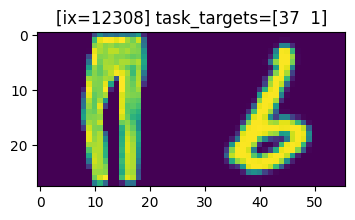

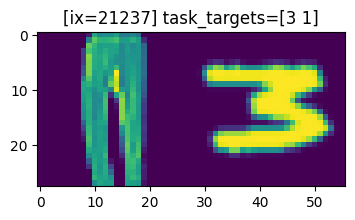

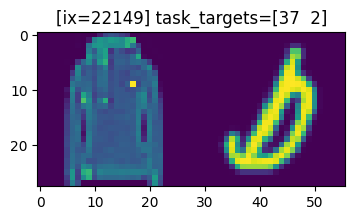

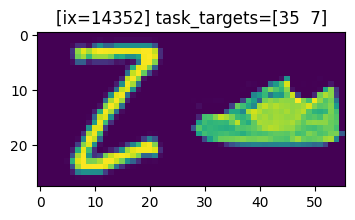

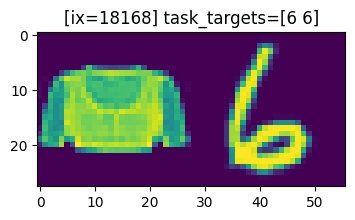

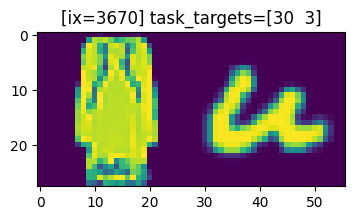

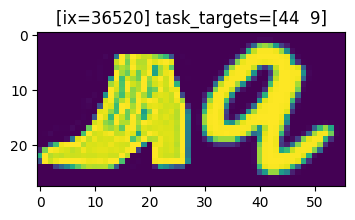

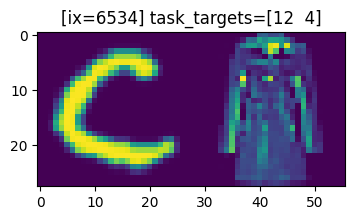

In [8]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)
        
        x = self.act2(self.conv2(x))
        x = self.max2(x)
        
        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [10]:
from torchvision.models.resnet import resnet18
from torch import nn

In [11]:
resnet18(num_classes=10);

In [12]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [13]:
pl.seed_everything(1)


dl_train_noshuffle = DataLoader(
    random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])[0],
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=DEVICE,
    default_root_dir="/tmp"
)

# trainer.fit(ModelWrapper(model), dl_train, dl_test)
# torch.save(model.state_dict(), "./model-cnn-multinist.pth")

model.load_state_dict(
    torch.load("./model-cnn-multinist.pth")
)
model = model.to(DEVICE)

model.eval()

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [14]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])
    metric_xent = MeanMetric()
    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
        metric_xent.update(F.cross_entropy(task_logit, task_target))
    acc =  float(metric.compute())
    xent = float(metric_xent.compute())
    return acc, xent
def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            # ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"], stats[f"xent_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_test': 0.8428000211715698,
 'xent_task_0_test': 0.5066717267036438,
 'acc_task_1_test': 0.8921999931335449,
 'xent_task_1_test': 0.33956974744796753}

# LRP Checking

In [15]:
GAMMA = 0.01

sanity_check: passed


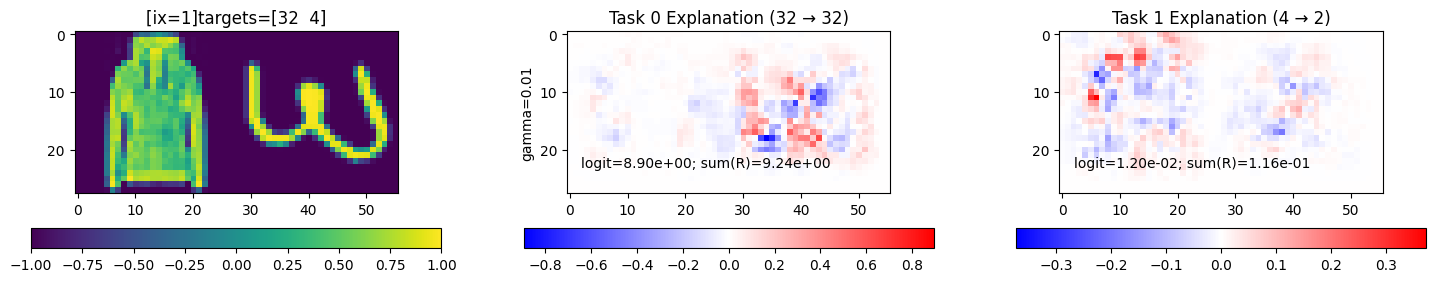

In [16]:


class TaskSpecificHeadModel(nn.Module):
    def __init__(self, model, task_id: int):
        super().__init__()
        self.model = model
        self.task_id = task_id 

    def forward(self, x):
        return self.model(x)[self.task_id]

def make_attributor(model):
    
    low = torch.tensor([-1.])
    high = torch.tensor([1.])

    composite = EpsilonGammaBox(low=low, high=high, gamma=GAMMA)

    return Gradient(model=model, composite=composite)


def sanity_check():

    task_id = 0

    logit_modifier = attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id])
    task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
    with make_attributor(task_specific_model) as attributor:
        x = torch.randn((7, 1, 28, 28*2)).to(DEVICE)
        
        _ = attributor.forward(x, lambda logits: logit_modifier(logits, None))
    print("sanity_check: passed")

sanity_check()

def viz_explain_tasks(sample_ix):

    ncols = 3
    plt.figure(figsize=(6*ncols, 3))

    x, y = ds_val[sample_ix]
    x = x.unsqueeze(0).to(DEVICE)

    plt.subplot(1, 3, 1)
    plt.title(f"[ix={sample_ix}]targets={y}")

    plt.imshow(x.detach().cpu().numpy().squeeze())
    plt.colorbar(location="bottom")
    for task_id in [0, 1]:
        task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
        
        with make_attributor(task_specific_model) as attributor:

            task_logits, heatmap = attributor.forward(
                x, 
                lambda logits: logits * F.one_hot(torch.tensor([y[task_id]]), num_classes=TASK_NUM_CLASSES[task_id]).to(logits.device)
            )

            task_logits = task_logits.detach().cpu().numpy()
            pred = np.argmax(task_logits)

            plt.subplot(1, ncols, task_id + 2)

            plt.title(f"Task {task_id} Explanation ({y[task_id]} → {pred})")
            if task_id == 0:
                plt.ylabel(f"gamma={GAMMA}")
            heatmap = heatmap.cpu().detach().numpy().squeeze()
            plt.text(2, 28-5, f"logit={task_logits[0, y[task_id]]:.2e}; sum(R)={heatmap.sum():.2e}")
            vmax = np.abs(heatmap).max()
            plt.imshow(heatmap, cmap="bwr", vmin=-vmax, vmax=vmax)
            plt.colorbar(location="bottom")
    
viz_explain_tasks(1)

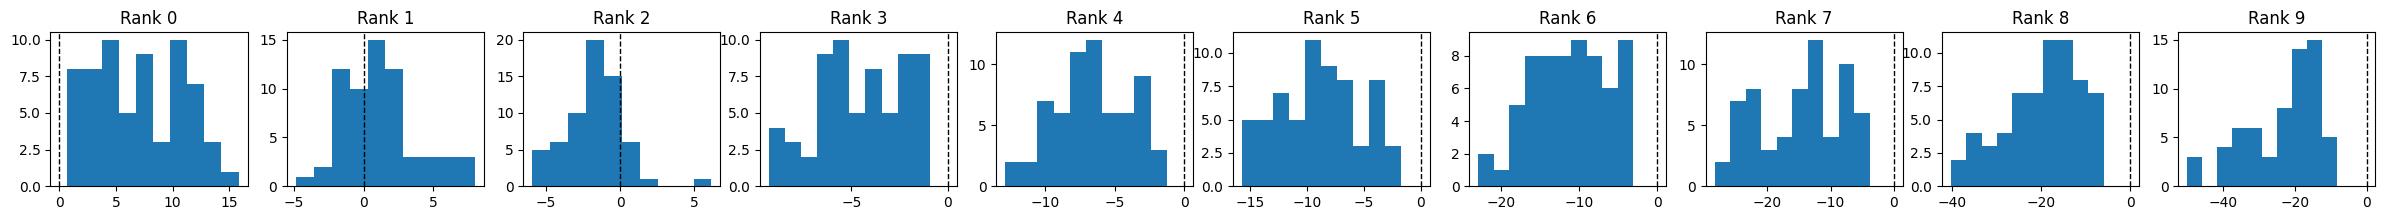

In [17]:
@torch.no_grad()
def check_winning_logits():

    ncols = 10
    task_id = 1
    plt.figure(figsize=(ncols*3, 2))
    for rank_ix in range(ncols):
        plt.subplot(1, ncols, rank_ix + 1)
        plt.title(f"Rank {rank_ix}")
        arr_winning_logits = []
        
        for x, _ in dl_train_noshuffle:
            logits = model(x.to(DEVICE))[task_id].detach().cpu()
            _, nc = logits.shape
            
            _, indices = torch.topk(logits, dim=1, k=ncols)
            one_hot = F.one_hot(
                indices[:, rank_ix], 
                num_classes=nc
            )
    
            rank_logits = (one_hot * logits).sum(dim=1)
            
            arr_winning_logits.extend(rank_logits.numpy().tolist())
    
            break
        plt.axvline(0, ls="--", lw=1, color="k")
        plt.hist(arr_winning_logits)
check_winning_logits()

# Extract Act and Ctx

In [18]:
ARR_LAYERS = ["max1", "max2", "act3"]

ARR_LAYERS

['max1', 'max2', 'act3']

In [19]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [20]:
from collections import OrderedDict

In [21]:
def split_model_for_task(model, layer, task_id):

    arr_name_layers = list(model.named_children())

    layer_names = list(map(lambda t: t[0], arr_name_layers))
    layer_ix = layer_names.index(layer)
    avgpool_ix = layer_names.index("avgpool")


    task_module_name = f"fc_task_{task_id+1}"
    
    task_module = getattr(model, task_module_name)

    first_module = nn.Sequential(OrderedDict(
        arr_name_layers[:layer_ix+1]
    ))
    second_module = nn.Sequential(OrderedDict(
        arr_name_layers[layer_ix+1:avgpool_ix+1] 
        + [
            ("flatten", nn.Flatten(start_dim=1)),
            (task_module_name, task_module)
        ]
    ))
    
    return first_module, second_module

@torch.no_grad()
def ano():


    trng = torch.Generator()
    trng.manual_seed(1)
    
    x = torch.randn(10, 1, 28, 56, generator=trng).to(DEVICE)
    
        
    for task_id in [0, 1]:
        for layer in ARR_LAYERS:
            m1, m2 = split_model_for_task(model, layer, task_id)

            actual = m2(m1(x)).cpu().numpy()
            expected = model(x)[task_id].cpu().numpy()
            np.testing.assert_allclose(
                actual,
                expected
            )
            print(f"sanity check: task_id={task_id} layer={layer} passed!")
ano()

sanity check: task_id=0 layer=max1 passed!
sanity check: task_id=0 layer=max2 passed!
sanity check: task_id=0 layer=act3 passed!
sanity check: task_id=1 layer=max1 passed!
sanity check: task_id=1 layer=max2 passed!
sanity check: task_id=1 layer=act3 passed!


In [58]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__


def compute_log_odd_winning(logits: torch.Tensor) -> torch.Tensor:

    ns, nc = logits.shape

    values, _ = torch.topk(logits, dim=1, k=nc)

    logit_winning = values[:, 0]
    lse_others = torch.logsumexp(values[:, 1:], dim=1)
    log_odd = logit_winning - lse_others

    return log_odd

        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits
        return compute_log_odd_winning(logits)


class DifferenceTop2WinningClasses(OutputQuantity):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        output = logits * F.one_hot(indices[:, 0], self.num_classes) - logits * F.one_hot(
            indices[:, 1], self.num_classes
        )
        return output

class LogitWinningClass(OutputQuantity):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        wining_targets = torch.argmax(logits, dim=1)
        return logits * F.one_hot(wining_targets, self.num_classes).to(
            logits.device
        )

        
class CrossEntropyOutput(OutputQuantity):
    def __call__(self, logits, targets):

        y_pred = torch.argmax(logits, dim=1)
        loss = F.cross_entropy(logits, y_pred, reduce="none")

        # convert to maximization problem
        loss = - loss
        return loss

In [23]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass
        
def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    output_quantity: OutputQuantity,
    rng: np.random.Generator,
    use_lrp: bool,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False,
):
    arr_act = []
    arr_ctx = []

    num_classes = TASK_NUM_CLASSES[task_id]

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        task_specific_head = TaskSpecificHeadModel(model, task_id=task_id)

        
        attributor = make_attributor(task_specific_head) if use_lrp else VoidAttributor()
        
        with attributor:
            for batch in tqdm(data_loader, desc=f"extract act ctx (use_lrp={use_lrp}; output_quantity={output_quantity.__class__.__name__}) at layer={layer}"):
                x, y = batch
                x = x.to(device)



                if use_lrp:
                    _ = attributor.forward(x, lambda logits: logit_mod(logits, y))

                    act = utils.interceptor.get_output(module)
                    assert act.grad is not None

                    rel = act.grad
    
                    output_dimensions = act.shape[1:]
    
                    ctx = torch.where(act.abs() > 0, rel / act, 0)
    
                    if strict_mode:
                        np.testing.assert_allclose(
                            (act * ctx).detach().cpu().numpy(),
                            rel.detach().cpu().numpy(),
                            atol=1e-6,
                        )

                else:
                    
                    logits = task_specific_head(x)
                    (output_quantity(logits, y)).sum().backward()
                    act = utils.interceptor.get_output(module)
                    output_dimensions = act.shape[1:]

                    assert act.grad is not None
                    ctx = act.grad

                assert ctx.shape == act.shape

                
                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, layer, output_quantity, dl, task_id, use_lrp):
    


    return extract_activation_context(
        model=model,
        layer=layer,
        data_loader=dl_train_noshuffle,
        task_id=task_id,
        output_quantity=output_quantity,
        rng=np.random.default_rng(seed=1),
        device=DEVICE,
        use_lrp=use_lrp
    )

extract_act_grad(model, "max2", CrossEntropyOutput(), dl_train_noshuffle, 0, use_lrp=False)
# extract_act_grad(model, "act3", "winning-0", dl_train_noshuffle, 0, use_lrp=False)

extract act ctx (use_lrp=False; output_quantity=CrossEntropyOutput) at layer=max2:   0%|          | 0/469 [00:…

/usr/local/lib/python3.11/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


max2: output-dims=torch.Size([256, 5, 12])


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[ 2.4210177e-11,  6.5743895e-12,  9.4856701e-12, ...,
         -2.5388009e-11,  3.0797587e-12,  3.4890398e-12],
        [-2.8214483e-11, -1.7904164e-11,  2.0542928e-11, ...,
         -1.9981187e-11, -2.5351563e-11, -3.3432895e-11],
        [ 2.8406793e-11,  3.3171493e-11, -1.8122608e-11, ...,
         -3.0830921e-11,  4.9157206e-11,  8.7966232e-11],
        ...,
        [ 2.3374369e-09,  2.3919933e-10, -1.7341648e-09, ...,
          2.2307489e-09,  1.2909247e-09,  2.5352946e-09],
        [-1.1197155e-08,  4.2753676e-09, -1.3119360e-08, ...,
         -2.0464963e-11,  1.4934589e-09,  8.4492466e-09],
        [-4.5452664e-09, -4.3951061e-09, -9.7669850e-10, ...,
          8.9329406e-09, -2.2268050e-09,  1.9578410e-09]], dt

In [24]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")

# sanity_check()

# Basis Construction

In [25]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

## Baseline

In [26]:
class BasisInterface:
    def get_projection(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U = _solve_eigvecs(cov)
        
    def get_projection(self, k: int):
        Uk = self.U[:, :k]
        return Uk @ Uk.T

In [67]:
# from https://github.com/jerry-chee/ModelPreserveCompressionNN/blob/main/id_utils.py
import scipy

def getID(k, Z, W=None, mode='kT'):
    '''
    calculates ID 
    mode: kT, WT (what to return)
    requires (d, n) format
    currently in numpy because pytorch doesn't support QR pivots
    k: number of columns
    Z: layer after nonlinearity
    ''' 
    assert(k <= Z.shape[1])
    # column-pivot QR
    R, P = scipy.linalg.qr((Z), mode='r', pivoting=True)
    if W is not None: Wk = W[:, P[0:k]]
    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    if mode == 'kT':
        return P[0:k], T
    elif mode == 'WT' and W is not None:
        return Wk, T
    else:
        raise NotImplementedError



class ActID(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        
    def get_projection(self, k: int):


        _, d = self.arr_act.shape
        
        k_idx, T = getID(k, self.arr_act)

        print(f"ActID[k={k}]: {k_idx}")
        # shape: (k, d)
        mat_selection = np.eye(d)[k_idx, :]

        return  T.T @ mat_selection
        

def sanity_check():
    arr_act = torch.randn((32, 128))
    
    basis = ActID(arr_act, None, None)

    mat_proj = basis.get_projection(k=7)

sanity_check()

ActID[k=7]: [ 49 122  88  16 103  22 115]


## RelID

In [42]:

    # @torch.no_grad()
    # def get_interpolative_decom(self, k: int, verbose=True):


    #     A = torch.from_numpy(self.arr_act).to(DEVICE)
    #     C = torch.from_numpy(self.arr_ctx).to(DEVICE)
    #     _, d = self.arr_act.shape


    #     all_dims = set(np.arange(d).tolist())
        
    #     selected = []
    #     eye = torch.eye(d).to(DEVICE)

    #     for _k in tqdm(range(k), desc="solve RelID", disable=False):

    #         arr_proj_candidates = []
    #         # arr_proj_candidates = []
    #         arr_criteria = []
    #         arr_candidate_dims = list(all_dims.difference(selected))
    #         for _, i in tqdm(enumerate(arr_candidate_dims), desc=f"_k={_k}", disable=True):
    #             _selected = [*selected, i]
    #             not_selected = list(all_dims.difference(_selected))
    #             A_k = A[:, _selected]

    #             A_k_pinv = torch.linalg.pinv(A_k)

    #             target = A[:, not_selected]
                

    #             mat_selected = eye[_selected].to(DEVICE)
                
    #             T = torch.zeros((len(_selected), d)).to(DEVICE)

    #             for k, _s in enumerate(_selected):
    #                 T[k, _s] = 1

    #             T[:, not_selected] = A_k_pinv @ target


    #             proj_mat = mat_selected.T @ T
        
    #             A_proj = A @ proj_mat

    #             residue = A_proj - A

    #             criteria = ((C * residue).sum(axis=1) ** 2).mean().detach().cpu()

    #             arr_proj_candidates.append((mat_selected.T.detach().cpu().numpy(), T.detach().cpu().numpy()))
    #             arr_criteria.append(criteria)

    #         best_ix = np.argmin(arr_criteria)
    #         best_proj_mat = arr_proj_candidates[best_ix]

    #         best_dim = arr_candidate_dims[best_ix]
    #         selected.append(best_dim)


    #     return selected, best_proj_mat

In [90]:
class RelID(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx

        self.selected = []
    @torch.no_grad()
    def get_interpolative_decom(self, k: int, verbose=True):


        A = torch.from_numpy(self.arr_act).to(DEVICE)
        C = torch.from_numpy(self.arr_ctx).to(DEVICE)
        _, d = self.arr_act.shape
        
        eye = torch.eye(d).to(DEVICE)


        all_dims = set(np.arange(d).tolist())

        if len(self.selected) - k >= 0:
            print("loading from cache!")
            selected = self.selected[:k]
            _, best_proj_mat = self._estimate(A, C, selected, all_dims, eye) 
            return selected, best_proj_mat
        
        selected = [*self.selected]
        # selected = []

        total_rounds = k - len(selected)
        
        for _k in tqdm(
            range(total_rounds), 
            desc="solve RelID", 
            disable=False
        ):

            arr_proj_candidates = []
            # arr_proj_candidates = []
            arr_criteria = []
            arr_candidate_dims = list(all_dims.difference(selected))

        
            arr_eval_dims = []
            for _, i in tqdm(enumerate(arr_candidate_dims), desc=f"_k={_k}", disable=True):

                if (self.arr_act[:, i] > 0).sum() == 0:
                    continue
                
                _selected = [*selected, i]
            
                criteria, (mat_selected, T) = self._estimate(A, C, _selected, all_dims, eye) 

                arr_proj_candidates.append(
                    (mat_selected, T)
                )
                arr_criteria.append(criteria)
                arr_eval_dims.append(i)

            if len(arr_eval_dims) == 0:
                break

            best_ix = np.argmin(arr_criteria)
            best_proj_mat = arr_proj_candidates[best_ix]
            best_dim = arr_eval_dims[best_ix]
            selected.append(best_dim)

        if total_rounds > 0:
            self.selected = selected

        return selected, best_proj_mat

   
        
    def get_projection(self, k, verbose=True):

        selected, (selection_mat, T) = self.get_interpolative_decom(k=k, verbose=verbose)

        print(f"RelID[k={k}]: {selected}")
        
        # assert T.shape[0] == k

        d = T.shape[1]
        
        np.testing.assert_allclose(
            np.eye(d)[selected, :].T,
            selection_mat
        )
        
        return T.T @ selection_mat.T
        
    def _estimate(self, A, C, _selected, all_dims, eye):
        not_selected = list(all_dims.difference(_selected))

        _, d = A.shape
        
        A_k = A[:, _selected]

        A_k_pinv = torch.linalg.pinv(A_k)

        target = A[:, not_selected]
        

        mat_selected = eye[_selected].to(DEVICE)
        
        T = torch.zeros((len(_selected), d)).to(DEVICE)

        for k, _s in enumerate(_selected):
            T[k, _s] = 1

        T[:, not_selected] = A_k_pinv @ target


        proj_mat = mat_selected.T @ T

        A_proj = A @ proj_mat

        residue = A_proj - A

        criteria = ((C * residue).sum(axis=1) ** 2).mean().detach().cpu()
        # print(f"Criteria {criteria}: {_selected}")
        
        return criteria, (mat_selected.detach().cpu().numpy().T, T.detach().cpu().numpy())

def sanity_check():
    # arr_act = torch.randn((32, 128)).numpy()
    # arr_ctx = torch.randn((32, 128)).numpy()

    arr_act, arr_ctx = extract_act_grad(model, "max2", LogOddWinningClass(), dl_train_noshuffle, 0, use_lrp=False)

    ActID(arr_act, None, None).get_projection(k=3)

    # mat_proj = basis.get_projection(k=7)

    basis = RelID(arr_act, arr_ctx)

    mat_proj = basis.get_projection(k=3)
    
    # mat_proj = basis.get_projection(k=1)

    print("Sanity check pass!")
sanity_check()

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max2:   0%|          | 0/469 [00:…

max2: output-dims=torch.Size([256, 5, 12])
ActID[k=3]: [141 184 163]


solve RelID:   0%|          | 0/3 [00:00<?, ?it/s]

RelID[k=3]: [228, 184, 79]
Sanity check pass!


## PRCARecon (non greedy)

In [83]:
def construct_fh(proj_mat):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            proj_mat.unsqueeze(2).unsqueeze(3)
            # (Uk@Uk.T)
        )
    return fh

def compute_task_acc_at_k(
    model, layer, task_id, 
    arr_ks, arr_ks_for_slow_learners,
    use_lrp=False,
    output_quantity=LogOddWinningClass(),
    arr_basis_classes=[PCA],
    base_output_dir="./artifacts/multinist-interdecom",
):
    # output_quantity = LogOddWinningClass()

    arr_act, arr_ctx = extract_act_grad(
        model, 
        layer, 
        dl=dl_train_noshuffle, task_id=task_id, output_quantity=output_quantity, use_lrp=use_lrp)

    arr_ks = sorted(list(set(arr_ks + arr_ks_for_slow_learners)))
    
    module = getattr(model, layer)

    rel = (arr_act  * arr_ctx).sum(axis=1)

    suffix = "relevance-lrp" if use_lrp else "relevance-grad"
    output_path = f"{base_output_dir}/task-{task_id}/{layer}/{suffix}"
    os.makedirs(output_path, exist_ok=True)

    arr_dfs = []

    for basis_class in arr_basis_classes:
        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
            task_id=task_id
        )
        basis_name = basis.__class__.__name__
        arr_stat_rows = []

        for k in tqdm(
            arr_ks_for_slow_learners if hasattr(basis, "is_slow") else arr_ks, 
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):

            proj_mat = basis.get_projection(k=k)

            # arr_recon_act = (arr_act @ Uk) @ Uk.T
            # residue = arr_act - arr_recon_act
            # recon_err = np.linalg.norm(residue, axis=1).mean()
            # projected_rel = ((arr_act @ Uk) * (arr_ctx @ Uk)).sum(axis=1)
            # rel_recon_err = ((rel - projected_rel) **2).mean()
            # assert rel.shape == projected_rel.shape == (rel.shape[0], )
            # perc_sign_align = (np.sign(rel) * np.sign(projected_rel)).mean()
            # cosine = ( 
            #     (arr_ctx / (np.linalg.norm(arr_ctx, axis=1, keepdims=True)) + 1e-6) \
            #     * (residue / (np.linalg.norm(residue, axis=1, keepdims=True)  + 1e-6))
            # ).sum(axis=1)
            # cosine = np.abs(cosine).mean()
            proj_mat = torch.from_numpy(proj_mat).float().to(DEVICE)
            row = dict(
                layer=layer,
                task_id=task_id, 
                output_quantity=output_quantity.__class__.__name__,
                gamma=GAMMA,
                k=k, 

                basis_name=basis_name,
                # recon_err=recon_err,
                # cosine=cosine,
                # rel_recon_err=rel_recon_err,
                # perc_sign_align=perc_sign_align,
            )
            try:
                hook = module.register_forward_hook(construct_fh(proj_mat))
                
                for label, dl in [
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
        df = pd.DataFrame(arr_stat_rows)
        df.to_csv(
            f"{output_path}/{basis_name}.csv",
            index=False
        )

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", "acc_test"], ascending=[True, False])
    print(f"Checking results at {output_path}")
    return df
    

compute_task_acc_at_k(
    model, layer="max2", 
    task_id=1, 
    arr_ks=[4],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
    ],
    output_quantity=LogitWinningClass(num_classes=10)
)

extract act ctx (use_lrp=False; output_quantity=LogitWinningClass) at layer=max2:   0%|          | 0/469 [00:0…

max2: output-dims=torch.Size([256, 5, 12])


[ActID               ] Estimating Performance:   0%|          | 0/1 [00:00<?, ?it/s]

ActID[k=4]: [141 184 163  73]


[RelID               ] Estimating Performance:   0%|          | 0/1 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/4 [00:00<?, ?it/s]

RelID[k=4]: [141, 96, 126, 231]
Checking results at ./tmp/task-1/max2/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,max2,1,LogitWinningClass,0.01,4,RelID,0.4645,1.958915
0,max2,1,LogitWinningClass,0.01,4,ActID,0.3130,1.965490


In [84]:
compute_task_acc_at_k(
    model, layer="act3", 
    task_id=1, 
    arr_ks=[8],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
    ],
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=act3:   0%|          | 0/469 [00:…

act3: output-dims=torch.Size([256, 3, 10])


[ActID               ] Estimating Performance:   0%|          | 0/1 [00:00<?, ?it/s]

ActID[k=8]: [ 54 153   7  41 187 184 101 221]


[RelID               ] Estimating Performance:   0%|          | 0/1 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

RelID[k=8]: [236, 233, 208, 5, 216, 196, 243, 117]
Checking results at ./tmp/task-1/act3/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,act3,1,LogOddWinningClass,0.01,8,RelID,0.7187,0.828320
0,act3,1,LogOddWinningClass,0.01,8,ActID,0.1000,3.173384


In [53]:
compute_task_acc_at_k(
    model, layer="act3", 
    task_id=0, 
    arr_ks=[4, 8, 16, 32, 64],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=act3:   0%|          | 0/469 [00:…

act3: output-dims=torch.Size([256, 3, 10])


[ActID               ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

[RelID               ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/4 [00:00<?, ?it/s]

...

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/16 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/32 [00:00<?, ?it/s]

Checking results at ./tmp/task-0/act3/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,act3,0,LogOddWinningClass,0.01,4,RelID,0.0891,3.894958
0,act3,0,LogOddWinningClass,0.01,4,ActID,0.0844,4.004477
1,act3,0,LogOddWinningClass,0.01,8,ActID,0.2824,2.729813
1,act3,0,LogOddWinningClass,0.01,8,RelID,0.2502,3.115088
2,act3,0,LogOddWinningClass,0.01,16,RelID,0.5210,1.702751
2,act3,0,LogOddWinningClass,0.01,16,ActID,0.5086,1.683161
3,act3,0,LogOddWinningClass,0.01,32,RelID,0.7767,0.690215
3,act3,0,LogOddWinningClass,0.01,32,ActID,0.7694,0.697152
4,act3,0,LogOddWinningClass,0.01,64,RelID,0.8477,0.495478
4,act3,0,LogOddWinningClass,0.01,64,ActID,0.8386,0.515123


In [91]:
compute_task_acc_at_k(
    model, layer="max2", 
    task_id=0, 
    arr_ks=[8, 16, 32],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max2:   0%|          | 0/469 [00:…

max2: output-dims=torch.Size([256, 5, 12])


[ActID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

ActID[k=8]: [141 184 163  73 187 126  79 231]
ActID[k=16]: [141 184 163  73 187 126  79 231 228  24   4 194  96 153 214 252]
ActID[k=32]: [141 184 163  73 187 126  79 231 228  24   4 194  96 153 214 252 232  17
  18  19  20  21  22  23   9  25  26  27  28  29  30  31]


[RelID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

...

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

RelID[k=16]: [228, 184, 79, 187, 231, 232, 252, 4, 141, 126, 214, 73, 163, 194, 153, 24]


solve RelID:   0%|          | 0/16 [00:00<?, ?it/s]

RelID[k=32]: [228, 184, 79, 187, 231, 232, 252, 4, 141, 126, 214, 73, 163, 194, 153, 24, 96]
Checking results at ./tmp/task-0/max2/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,max2,0,LogOddWinningClass,0.01,8,RelID,0.5802,1.501899
0,max2,0,LogOddWinningClass,0.01,8,ActID,0.5383,1.572082
1,max2,0,LogOddWinningClass,0.01,16,RelID,0.8401,0.517739
1,max2,0,LogOddWinningClass,0.01,16,ActID,0.8348,0.524432
2,max2,0,LogOddWinningClass,0.01,32,ActID,0.8428,0.506672
2,max2,0,LogOddWinningClass,0.01,32,RelID,0.8428,0.506672


In [92]:
compute_task_acc_at_k(
    model, layer="max2", 
    task_id=1, 
    arr_ks=[8, 16, 32],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max2:   0%|          | 0/469 [00:…

max2: output-dims=torch.Size([256, 5, 12])


[ActID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

ActID[k=8]: [141 184 163  73 187 126  79 231]
ActID[k=16]: [141 184 163  73 187 126  79 231 228  24   4 194  96 153 214 252]
ActID[k=32]: [141 184 163  73 187 126  79 231 228  24   4 194  96 153 214 252 232  17
  18  19  20  21  22  23   9  25  26  27  28  29  30  31]


[RelID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

...

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

RelID[k=16]: [141, 126, 96, 163, 187, 228, 232, 184, 214, 231, 153, 73, 24, 252, 4, 79]


solve RelID:   0%|          | 0/16 [00:00<?, ?it/s]

RelID[k=32]: [141, 126, 96, 163, 187, 228, 232, 184, 214, 231, 153, 73, 24, 252, 4, 79, 194]
Checking results at ./tmp/task-1/max2/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,max2,1,LogOddWinningClass,0.01,8,RelID,0.6952,0.964740
0,max2,1,LogOddWinningClass,0.01,8,ActID,0.6277,1.176789
1,max2,1,LogOddWinningClass,0.01,16,ActID,0.8863,0.353329
1,max2,1,LogOddWinningClass,0.01,16,RelID,0.8800,0.368365
2,max2,1,LogOddWinningClass,0.01,32,ActID,0.8922,0.339570
2,max2,1,LogOddWinningClass,0.01,32,RelID,0.8922,0.339570


In [57]:
compute_task_acc_at_k(
    model, layer="max1", 
    task_id=0, 
    arr_ks=[8, 16, 32],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max1:   0%|          | 0/469 [00:…

max1: output-dims=torch.Size([256, 13, 27])


[ActID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[RelID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/16 [00:00<?, ?it/s]

Checking results at ./tmp/task-0/max1/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,max1,0,LogOddWinningClass,0.01,8,RelID,0.7682,0.798152
0,max1,0,LogOddWinningClass,0.01,8,ActID,0.7364,0.881047
1,max1,0,LogOddWinningClass,0.01,16,RelID,0.8147,0.599710
1,max1,0,LogOddWinningClass,0.01,16,ActID,0.8065,0.611253
2,max1,0,LogOddWinningClass,0.01,32,ActID,0.8347,0.525575
2,max1,0,LogOddWinningClass,0.01,32,RelID,0.8335,0.525878


In [55]:
compute_task_acc_at_k(
    model, layer="max1", 
    task_id=1, 
    arr_ks=[8, 16, 32],
    arr_ks_for_slow_learners=[],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        ActID,
        RelID,
     ]
)

extract act ctx (use_lrp=False; output_quantity=LogOddWinningClass) at layer=max1:   0%|          | 0/469 [00:…

max1: output-dims=torch.Size([256, 13, 27])


[ActID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[RelID               ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/8 [00:00<?, ?it/s]

solve RelID:   0%|          | 0/16 [00:00<?, ?it/s]

Checking results at ./tmp/task-1/max1/relevance-grad


,layer,task_id,output_quantity,gamma,k,basis_name,acc_test,xent_test
0,max1,1,LogOddWinningClass,0.01,8,RelID,0.8122,0.546920
0,max1,1,LogOddWinningClass,0.01,8,ActID,0.7200,0.824760
1,max1,1,LogOddWinningClass,0.01,16,RelID,0.8619,0.407498
1,max1,1,LogOddWinningClass,0.01,16,ActID,0.8078,0.564248
2,max1,1,LogOddWinningClass,0.01,32,RelID,0.8796,0.361916
2,max1,1,LogOddWinningClass,0.01,32,ActID,0.8746,0.380643


In [ ]:
raise
# compute_task_acc_at_k(
#     model, layer="act3", 
#     task_id=0, 
#     arr_ks=[5, 10, 15, 256],
#     arr_ks_for_slow_learners=[5, 10, 15],
#     base_output_dir="./tmp",
#     output_quantity=DifferenceTop2WinningClasses(num_classes=TASK_NUM_CLASSES[0]),
#     arr_basis_classes=[ 
#         # PRCAReconNormGrad,
#         # PCA,
#         GradPCA,
#         # PRCA,
#         PRCASortAbs,
#         # PRCARecon
#      ]
# )

In [ ]:
compute_task_acc_at_k(
    model, layer="act3", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    output_quantity=LogitWinningClass(num_classes=TASK_NUM_CLASSES[0]),
    arr_basis_classes=[ 
        # PRCAReconNormGrad,
        # PCA,
        GradPCA,
        # PRCA,
        PRCASortAbs,
        # PRCARecon
     ]
)

In [ ]:
raise

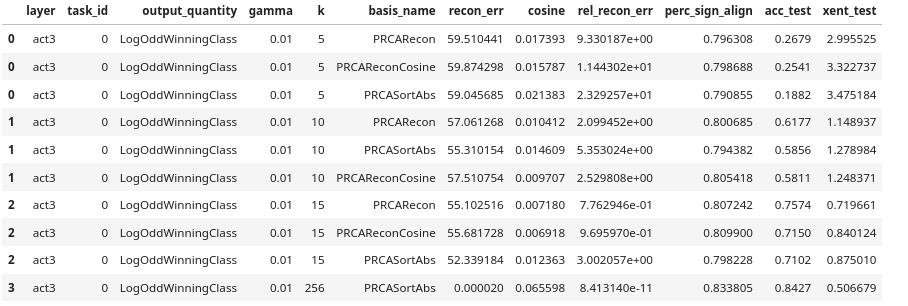

!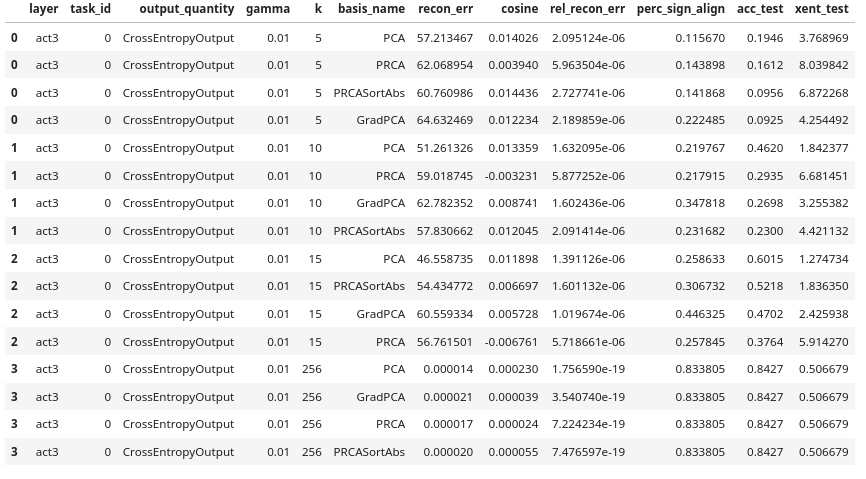

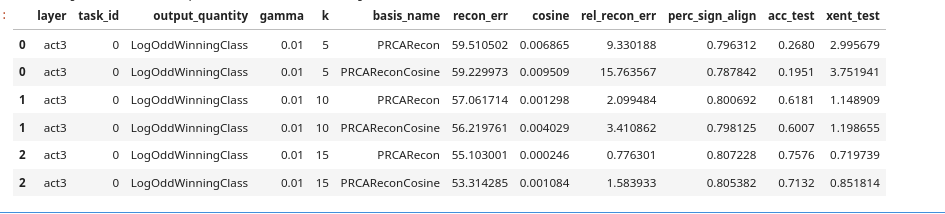

In [ ]:
torch.log(1 - torch.sigmoid(torch.Tensor([1.])))

In [ ]:
compute_log_odd_winning

In [ ]:
compute_task_acc_at_k(
    model, layer="max2", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCARecon
     ]
)

In [ ]:
compute_task_acc_at_k(
    model, layer="max1", 
    task_id=0, 
    arr_ks=[5, 10, 15, 256],
    arr_ks_for_slow_learners=[5, 10, 15],
    base_output_dir="./tmp",
    arr_basis_classes=[ 
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCARecon
     ]
)

# Computing Results

In [ ]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

In [ ]:

for use_lrp in [False]:
    for layer in  tqdm(["act3", "max2", "max1"], f"use_lrp={use_lrp}"):
        d = get_dims(layer)

        arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]
        for task_id in [0, 1]:

            compute_task_acc_at_k(
                model, layer=layer, 
                task_id=task_id, 
                arr_ks=arr_ks,
                arr_ks_for_slow_learners=arr_ks,
                use_lrp=use_lrp,
                arr_basis_classes=[ 
                    PCA, GradPCA,
                    
                    PRCA,     
                    PRCASortAbs,

                    PRCARecon,
            
                ]
        )

In [ ]:
print(f"Finished at {datetime.now()}")